In [1]:
!pip -q install pandas numpy matplotlib seaborn plotly scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving startup_funding.csv to startup_funding.csv


In [4]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.shape)
df.head()

(3044, 10)


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [5]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",nan
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",nan
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",nan
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",nan
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",nan


In [6]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  3044 non-null   object
 4   SubVertical        3044 non-null   object
 5   City  Location     3044 non-null   object
 6   Investors Name     3044 non-null   object
 7   InvestmentnType    3044 non-null   object
 8   Amount in USD      3044 non-null   object
 9   Remarks            3044 non-null   object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB
None

Missing Values:
Sr No                0
Date dd/mm/yyyy      0
Startup Name         0
Industry Vertical    0
SubVertical          0
City  Location       0
Investors Name       0
InvestmentnType      0
Amount in USD        0
Remarks              0
dtype: int64


In [7]:
possible_cols = [c for c in df.columns if 'amount' in c.lower()]

print(possible_cols)

funding_col = possible_cols[0]

df[funding_col] = (
    df[funding_col]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df[funding_col] = pd.to_numeric(
    df[funding_col],
    errors='coerce'
)

df[funding_col] = df[funding_col].fillna(0)

df[funding_col].describe()

['Amount in USD']


,Amount in USD
count,3.044000e+03
mean,1.250254e+07
std,1.003304e+08
min,0.000000e+00
25%,0.000000e+00
50%,5.000000e+05
75%,4.000000e+06
max,3.900000e+09


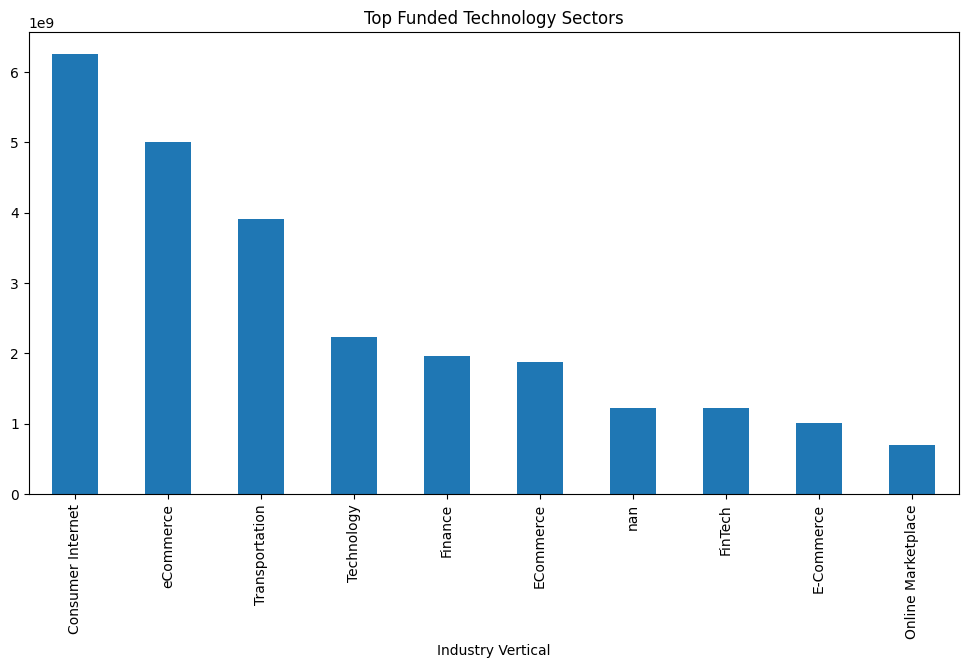

In [8]:
sector_col = [c for c in df.columns if 'industry' in c.lower()]

if len(sector_col) > 0:

    sector_col = sector_col[0]

    top_sectors = (
        df.groupby(sector_col)[funding_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))
    top_sectors.plot(kind='bar')
    plt.title("Top Funded Technology Sectors")
    plt.show()

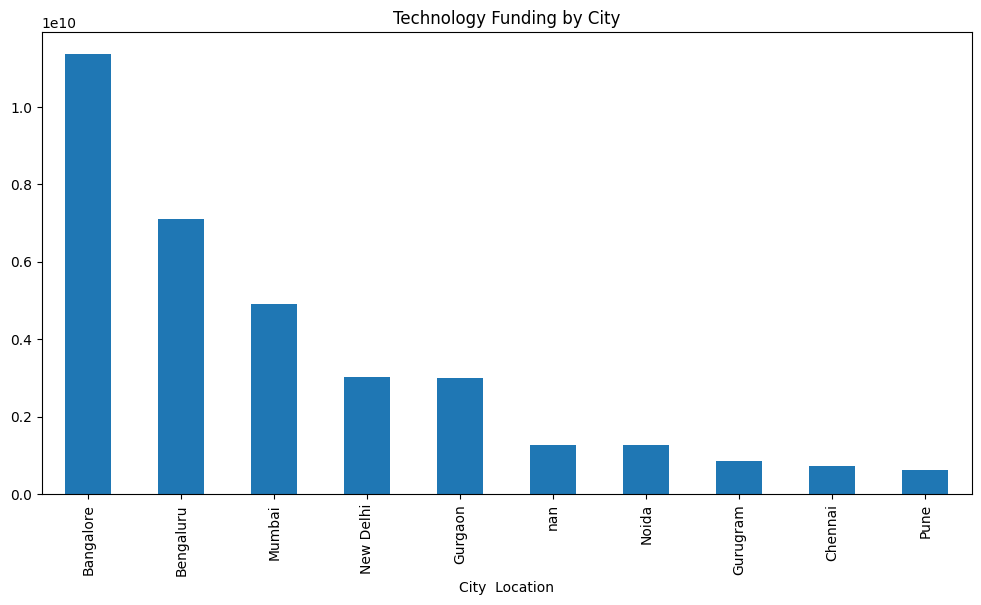

In [9]:
city_col = [c for c in df.columns if 'city' in c.lower()]

if len(city_col) > 0:

    city_col = city_col[0]

    city_funding = (
        df.groupby(city_col)[funding_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))
    city_funding.plot(kind='bar')
    plt.title("Technology Funding by City")
    plt.show()

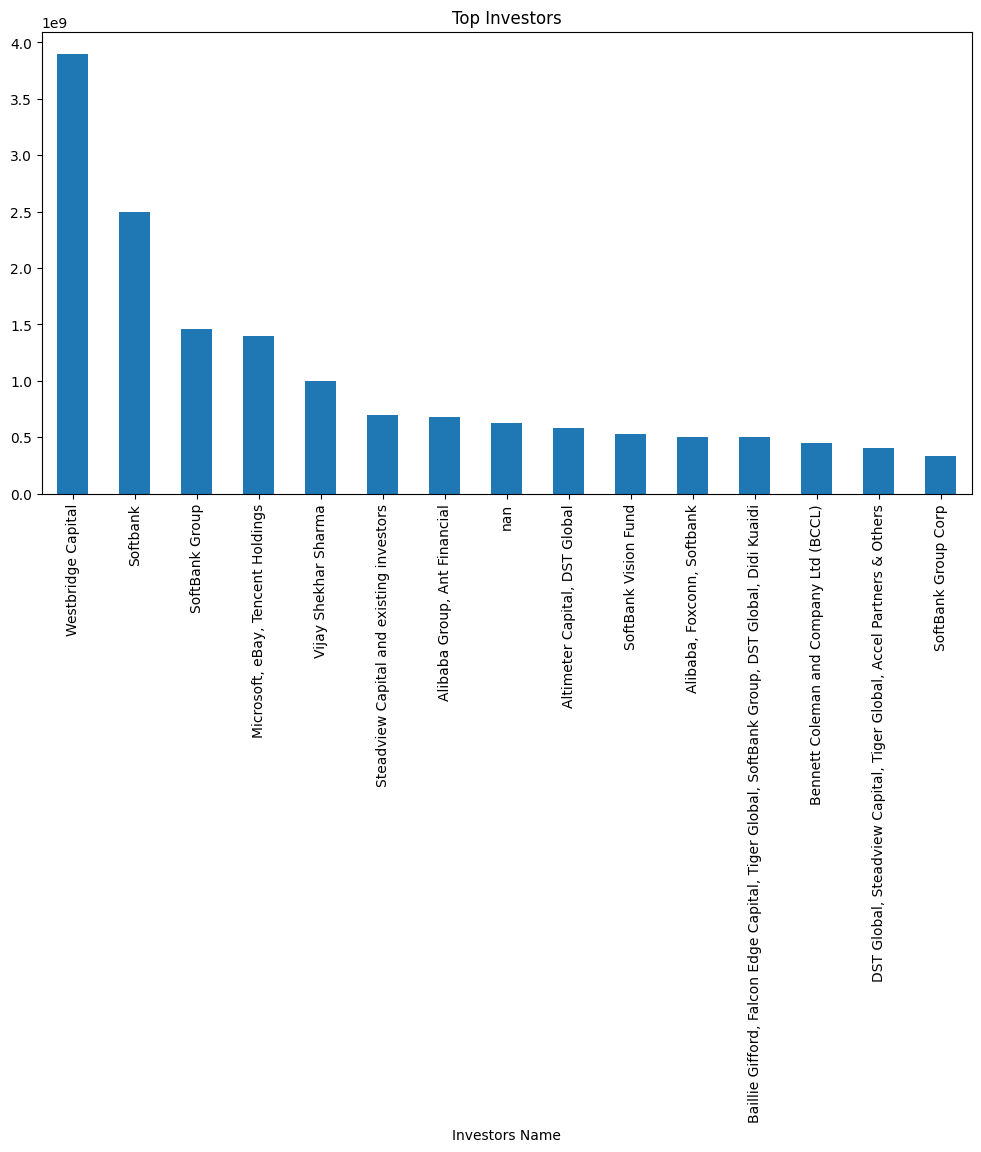

In [10]:
investor_col = [c for c in df.columns if 'investor' in c.lower()]

if len(investor_col) > 0:

    investor_col = investor_col[0]

    top_investors = (
        df.groupby(investor_col)[funding_col]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12,6))
    top_investors.plot(kind='bar')
    plt.title("Top Investors")
    plt.show()

In [11]:
startup_col = [c for c in df.columns if 'startup' in c.lower()]

startup_col = startup_col[0]

company_scores = (
    df.groupby(startup_col)[funding_col]
    .sum()
    .reset_index()
)

scaler = MinMaxScaler()

company_scores['Due_Diligence_Score'] = scaler.fit_transform(
    company_scores[[funding_col]]
) * 100

company_scores = company_scores.sort_values(
    "Due_Diligence_Score",
    ascending=False
)

company_scores.head(20)

,Startup Name,Amount in USD,Due_Diligence_Score
689,Flipkart,4.059700e+09,100.000000
1654,Rapido Bike Taxi,3.900000e+09,96.066212
1513,Paytm,3.148950e+09,77.566076
1453,Ola,9.845000e+08,24.250560
2119,Udaan,8.700000e+08,21.430155
1872,Snapdeal,7.000000e+08,17.242653
690,Flipkart.com,7.000000e+08,17.242653
1454,Ola Cabs,6.697000e+08,16.496293
2097,True North,6.000000e+08,14.779417
198,BigBasket,5.070000e+08,12.488608


In [12]:
fig = px.bar(
    company_scores.head(15),
    x=startup_col,
    y='Due_Diligence_Score',
    title='Top Technology Companies by Due Diligence Score'
)

fig.show()

In [13]:
top_company = company_scores.iloc[0][startup_col]

top_score = company_scores.iloc[0]['Due_Diligence_Score']

print("EXECUTIVE MARKET INTELLIGENCE REPORT")
print("="*50)

print(f"\nTop Company: {top_company}")

print(f"Due Diligence Score: {round(top_score,2)}")

print("\nKey Findings:")

print("- Strong funding concentration among market leaders")
print("- Investor activity highlights emerging opportunities")
print("- Competitive landscape favors highly funded firms")
print("- Technology ecosystem shows strong growth potential")
print("- Market intelligence suggests continued innovation")

EXECUTIVE MARKET INTELLIGENCE REPORT

Top Company: Flipkart
Due Diligence Score: 100.0

Key Findings:
- Strong funding concentration among market leaders
- Investor activity highlights emerging opportunities
- Competitive landscape favors highly funded firms
- Technology ecosystem shows strong growth potential
- Market intelligence suggests continued innovation


In [14]:
company_scores.to_excel(
    "Technology_Market_Intelligence_Report.xlsx",
    index=False
)

print("Report Generated Successfully")

Report Generated Successfully


In [15]:
from google.colab import files

files.download(
    "Technology_Market_Intelligence_Report.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>